In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = r'C:\Users\User\OneDrive\Desktop\AIML\outputs\outputs'

In [3]:
categories = os.listdir(data_path)
print(categories)

['Disappointed', 'Interested', 'Neutral']


In [4]:
# --- Define the Parameters ---

In [5]:
img_height = 50
img_width = 50

img_size = (img_height, img_width)
b_size = 64

In [6]:
print("Loading training data....")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading training data....
Found 34395 files belonging to 3 classes.
Using 27516 files for training.


In [7]:
print("Loading validation data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123, # Using a seed ensures the split is reproducible
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading validation data...
Found 34395 files belonging to 3 classes.
Using 6879 files for validation.


In [8]:
class_names = train_dataset.class_names
print(f"Found class names: {class_names}")

Found class names: ['Disappointed', 'Interested', 'Neutral']


In [9]:
# Optimize performance by caching and prefetching the data
autotune = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size = autotune)
validation_dataset = validation_dataset.cache().prefetch(buffer_size = autotune)

In [10]:
model = Sequential([
    Input(shape=(img_height, img_width, 1)),
    
    Rescaling(1./255), 
    
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(3, activation='softmax')
])

In [11]:
# --- COMPILE THE MODEL ---

In [12]:
model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 50, 50, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 50, 50, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 50, 50, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 25, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 25, 25, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 25, 25, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,907 (2.61 MB)

 Trainable params: 683,459 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
# --- TRAIN THE MODEL ---

In [16]:
print("\nStarting model training....")

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 60
)

print("\nTraining complete...")


Starting model training....
Epoch 1/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 49s 115ms/step - accuracy: 0.5343 - loss: 0.9406 - val_accuracy: 0.5661 - val_loss: 0.9000
Epoch 2/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 49s 115ms/step - accuracy: 0.5580 - loss: 0.8964 - val_accuracy: 0.5781 - val_loss: 0.8711
Epoch 3/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 51s 118ms/step - accuracy: 0.5886 - loss: 0.8569 - val_accuracy: 0.5979 - val_loss: 0.8436
Epoch 4/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 50s 117ms/step - accuracy: 0.6103 - loss: 0.8189 - val_accuracy: 0.6046 - val_loss: 0.8292
Epoch 5/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 48s 112ms/step - accuracy: 0.6347 - loss: 0.7836 - val_accuracy: 0.6172 - val_loss: 0.8154
Epoch 6/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 52s 120ms/step - accuracy: 0.6528 - loss: 0.7444 - val_accuracy: 0.6232 - val_loss: 0.8070
Epoch 7/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 48s 113ms/step - accuracy: 0.6767 - loss: 0.7125 - val_accuracy: 0.6231 - val_loss: 0.8064
Epoch 8/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step

In [17]:
# --- EVALUATE AND VISUALIZE THE RESULTS ---


Evaluating model on validation data....
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6452 - loss: 1.8208
Final Validation Accuracy: 64.52%


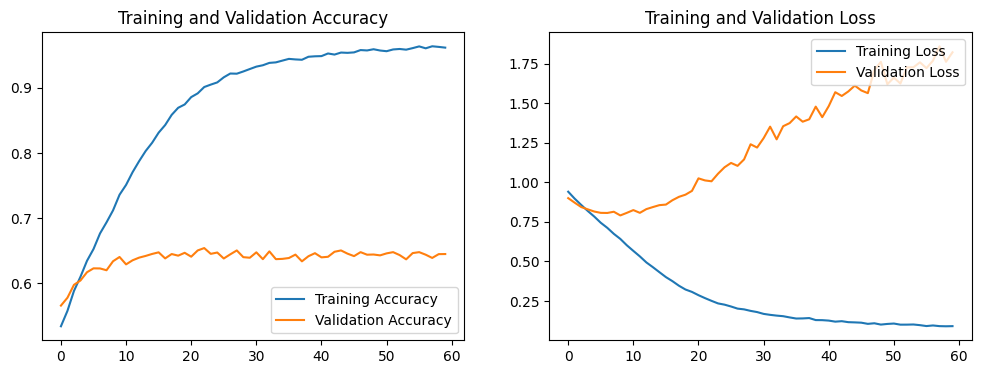

In [18]:
print("\nEvaluating model on validation data....")
loss, accuracy = model.evaluate(validation_dataset)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")


# Plot the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(60)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ------------ The Classification Report ------------

In [ ]:
print("Gathering predictions from validation set...")
y_pred = [] 
y_true = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("Predictions gathered...")

print("Classification Report")
print("---" * 10)

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# ------------ The Confusion Matrix ------------

In [ ]:
print("Generating Confusion Matrix...")
print("---" * 10)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()